In [75]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt

In [76]:
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]
y = (iris["target"] == 2).astype(np.float64)
svm_clf = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("linear_svc", LinearSVC(C=1, loss="hinge")),
    ]
)
svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge'))])

In [77]:
svm_clf.predict([[5.5,1.7]])

array([1.])

In [81]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC

X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)

train_size = int(len(X) * 0.8)

polynomial_svm_clf = Pipeline(
    [
        ("poly_features", PolynomialFeatures(degree=3)),
        ("scaler", StandardScaler()),
        ("svm_clf", LinearSVC(C=10, loss="hinge")),
    ]
)

polynomial_svm_clf.fit(X[:train_size], y[:train_size])

c:\Users\Haji Suleman\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('poly_features', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=10, loss='hinge'))])

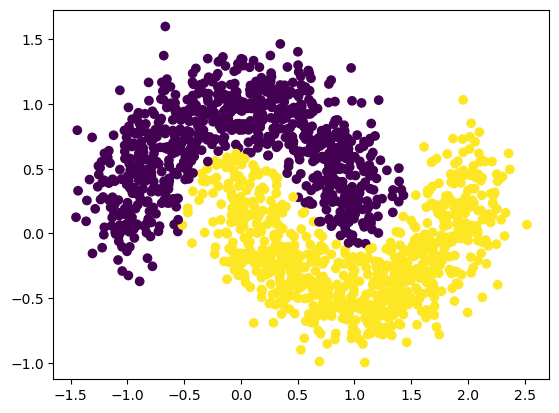

In [82]:
y_predicted = polynomial_svm_clf.predict(X[:train_size])
x_tester = X[:train_size]
plt.scatter(x_tester[:, 0], x_tester[:, 1],c=y_predicted)

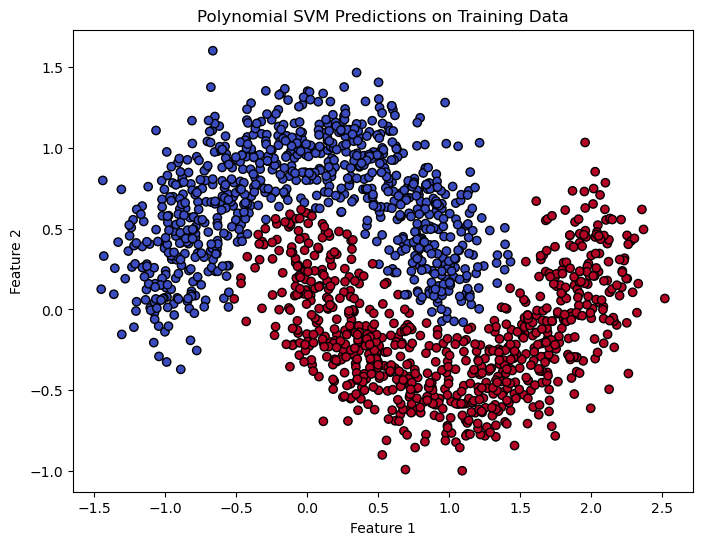

In [83]:
import matplotlib.pyplot as plt

y_predicted = polynomial_svm_clf.predict(X[:train_size])
x_tester = X[:train_size]

plt.figure(figsize=(8, 6))
plt.scatter(
    x_tester[:, 0], x_tester[:, 1], c=y_predicted, cmap="coolwarm", edgecolors="k"
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Polynomial SVM Predictions on Training Data")
plt.savefig("./coolwarm.png")
plt.show()

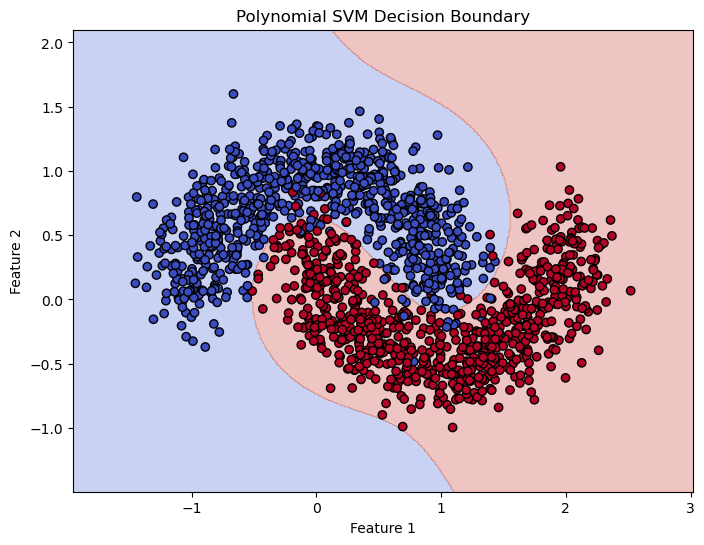

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Use your polynomial SVM and data
model = polynomial_svm_clf
X_plot = X[:train_size]
y_plot = y[:train_size]

# Create a mesh of points
x0_min, x0_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
x1_min, x1_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
xx0, xx1 = np.meshgrid(
    np.linspace(x0_min, x0_max, 500), np.linspace(x1_min, x1_max, 500)
)

# Predict on the mesh points
mesh_points = np.c_[xx0.ravel(), xx1.ravel()]
Z = model.predict(mesh_points)
Z = Z.reshape(xx0.shape)

# Plot the decision boundary and data points
plt.figure(figsize=(8, 6))
plt.contourf(xx0, xx1, Z, cmap="coolwarm", alpha=0.3)  # decision regions
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, cmap="coolwarm", edgecolors="k")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Polynomial SVM Decision Boundary")
plt.savefig("Decision_boundary.png")
plt.show()